#### Loaded only one file ".24" and taken Fs as 20480 (sampling rate). Marked the time "t" cause we will be plotting time series data. Plotted 2000 data from the file.

Total samples: 20480


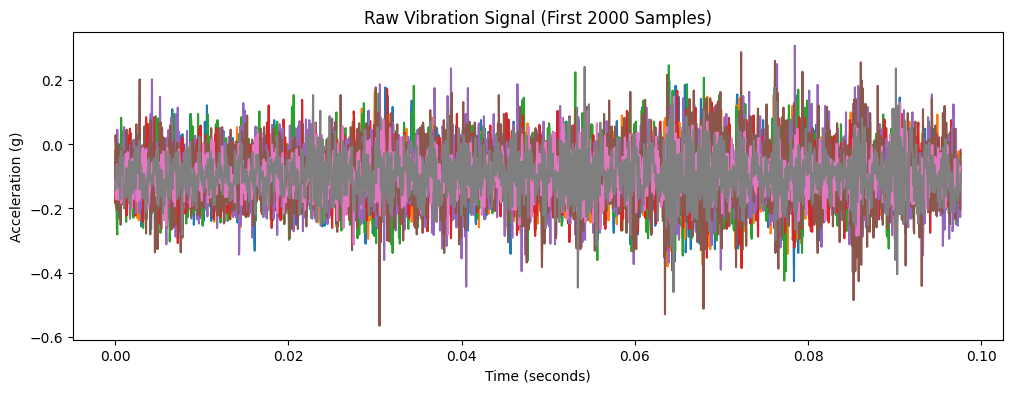

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
# Load raw vibration data
data = np.loadtxt("../data/2003.10.22.12.06.24")

Fs = 20480  # Sampling rate (Hz)
t = np.arange(len(data)) / Fs

print("Total samples:", len(data))
plt.figure(figsize=(12,4))
plt.plot(t[:2000], data[:2000])
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Vibration Signal (First 2000 Samples)")
plt.show()

#### As the data is not centred around zero so we did the DC offset removing to centre it around the 0.

In [2]:
data_dc = data - np.mean(data)
print("Mean before:", np.mean(data))
print("Mean after :", np.mean(data_dc))

Mean before: -0.09286718139648438
Mean after : 4.206704429243757e-18


#### Used z score method for basic outlier detection in one file with the kernel size of 5. Then copied the data for the no loss in future to prevent the originality.

In [3]:
mean = np.mean(data_dc)
std = np.std(data_dc)

z_scores = (data_dc - mean) / std
outliers = np.abs(z_scores) > 5
cleaned_data = np.copy(data_dc)
cleaned_data[outliers] = mean # replaces spike with mean value over 5 kernel.
from scipy.signal import medfilt
# median filter used for fine tuning the spikes.
filtered = medfilt(cleaned_data, kernel_size=5) # This is the median filter to filter and normalize the spike.


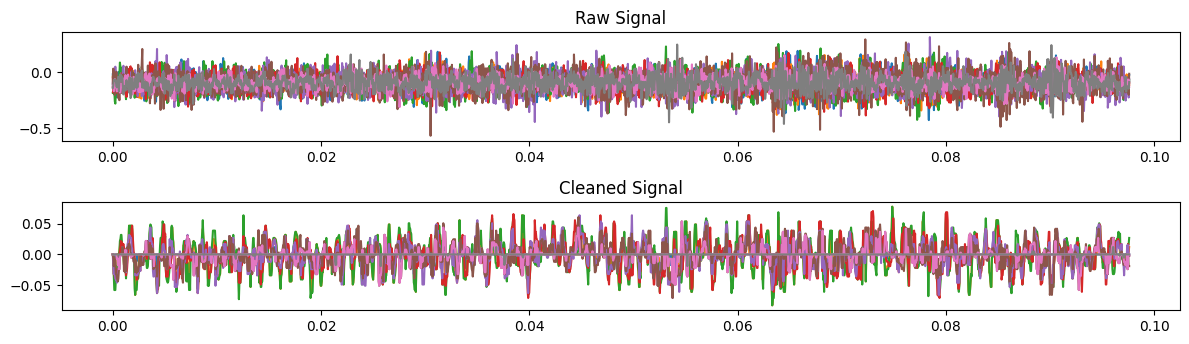

In [4]:
#Plotted the raw and cleaned data for comparison.
plt.figure(figsize=(12,5))

plt.subplot(3,1,1)
plt.plot(t[:2000], data[:2000])
plt.title("Raw Signal")

plt.subplot(3,1,2)
plt.plot(t[:2000], filtered[:2000])
plt.title("Cleaned Signal")


plt.tight_layout()
plt.show()

### *FFT freq domain data

In [5]:
print(cleaned_data.shape) # here we are checking how much channel is there for the signal data and it comes out to be 8 so we individually check the data in each channel of the signal in the above code.

(20480, 8)


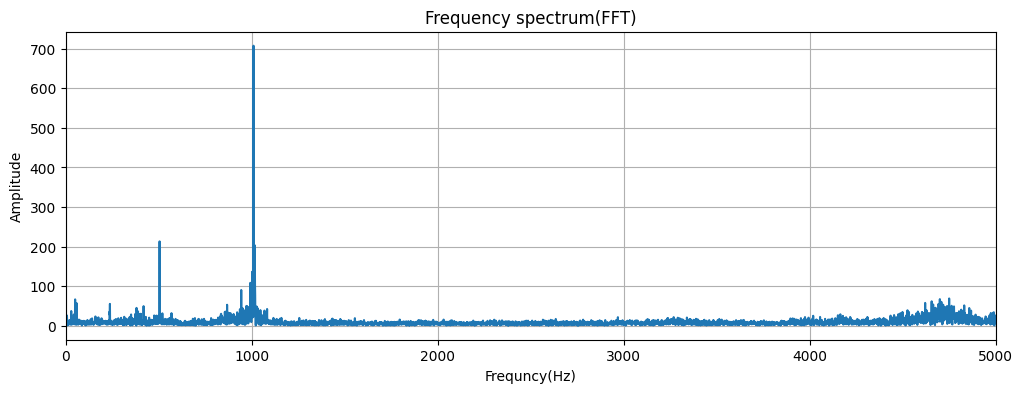

In [6]:
from scipy.fft import rfft, rfftfreq
signal=cleaned_data[:,2]#taking the 2nd channel data
N=len(signal)
Fs=20480
yf=rfft(signal)
xf=rfftfreq(N,1/Fs)
magnitude=np.abs(yf) # shows the absolute value of yf means the original yf would be in complex number and the absolute value is the root of the complex value.
plt.figure(figsize=(12,4))
plt.plot(xf,magnitude)
plt.xlim(0,5000)# Upto 20480/2 <= 10240 ~ 10000 we can take the limit of x
plt.xlabel("Frequncy(Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum(FFT)")
plt.grid()
plt.show()

### windowing

In [7]:
signal=cleaned_data[:,2]
from scipy.signal import windows
window=windows.hann(len(signal)) #Using hanning window.
signal_win=signal*window # This new signal is the the windowed one to.
from scipy.fft import rfft, rfftfreq
Fs=20480
N1=len(signal_win)
yf_w=rfft(signal_win)
xf_w=rfftfreq(N,1/Fs)
mag=np.abs(yf_w) #It is for saving the magnitude of the yf_w cause it is saved in the complex form.

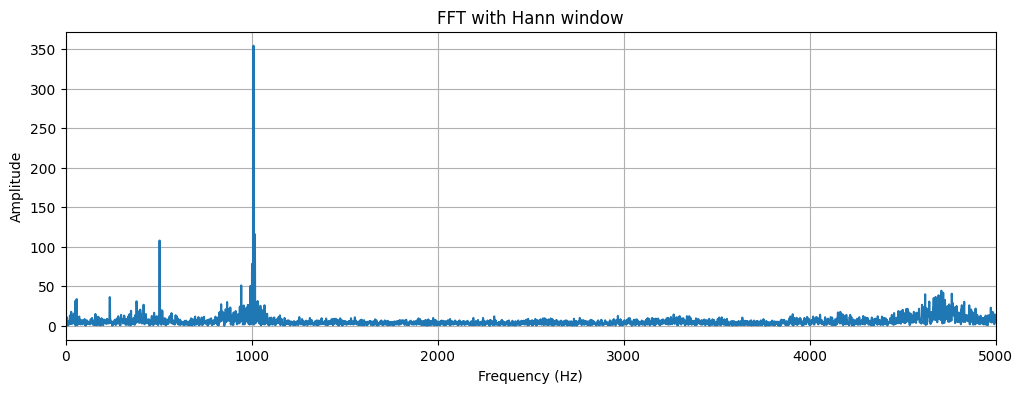

In [8]:
plt.figure(figsize=(12,4))
plt.plot(xf,mag)
plt.xlim(0,5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT with Hann window")
plt.grid()
plt.show()

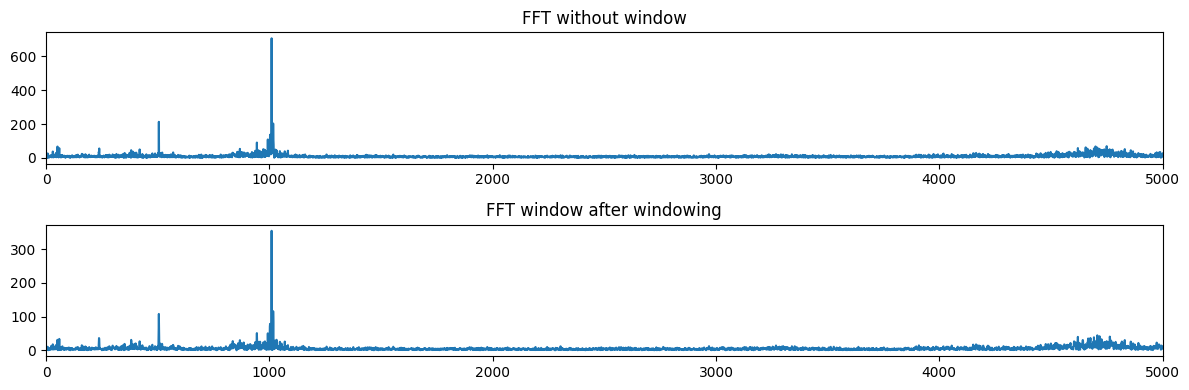

In [9]:
# Comparing windowed vs non windowed for clarification.
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(xf, magnitude)
plt.title("FFT without window")
plt.xlim(0,5000)

plt.subplot(2,1,2)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

### PSD using welch's method after FFT

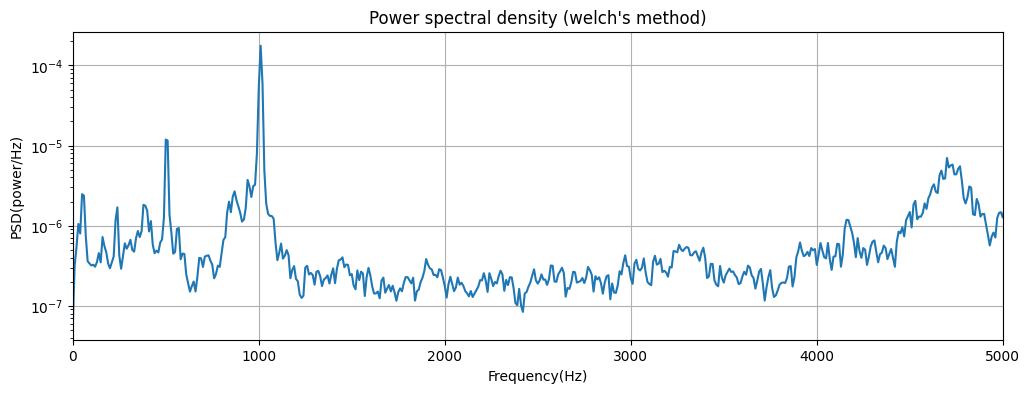

In [10]:
from scipy.signal import welch

Fs = 20480
signal = cleaned_data[:, 2]   # channel 2

freqs, psd = welch(  #Declaring PSD function.
    signal,
    fs=Fs,
    window='hann',
    nperseg=2048, # Defining segement length
    noverlap=1024, # DEfining overlap length
    scaling='density'
)
plt.figure(figsize=(12,4))
plt.semilogy(freqs,psd)
plt.title("Power spectral density (welch's method)")
plt.xlabel("Frequency(Hz)")
plt.ylabel("PSD(power/Hz)")
plt.xlim(0,5000)
plt.grid()
plt.show()

### Plotting of FFT and PSD

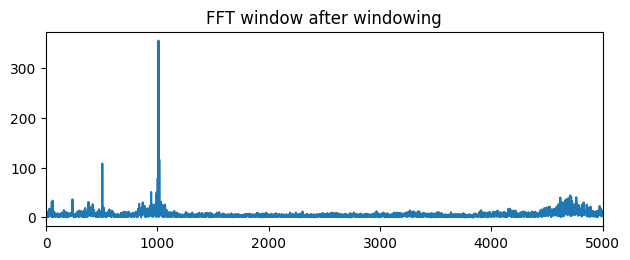

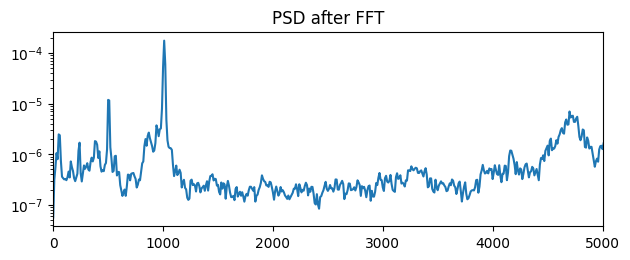

In [11]:
#Plotting FFT vs PSD
plt.subplot(2,1,1)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

plt.subplot(2,1,2)
plt.semilogy(freqs, psd) #plotting using log scale.
plt.title("PSD after FFT")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()


### STFT and Spectrogram

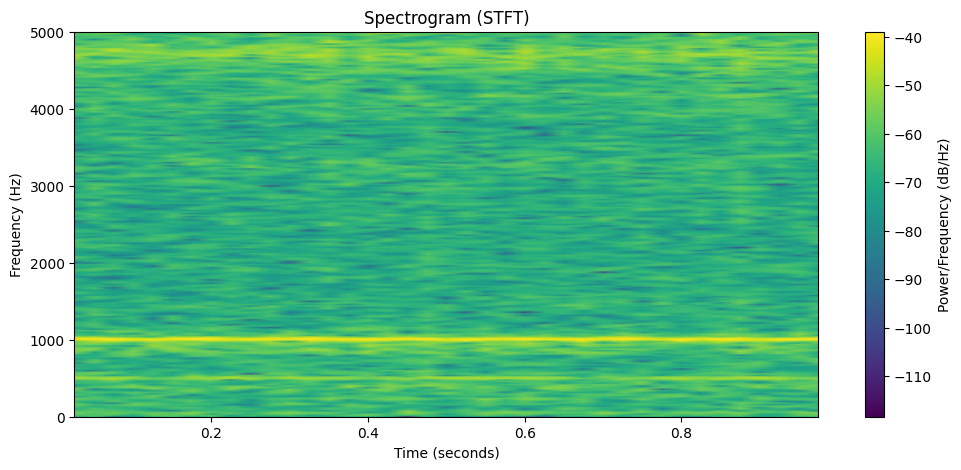

In [12]:
sig1 = cleaned_data[:, 2]
Fs = 20480
from scipy.signal import spectrogram

f, t, Sxx = spectrogram( #defining Spectogram function with all the parameters
    sig1,
    fs=Fs,
    window='hann',
    nperseg=1024,
    noverlap=512,
    scaling='density'
)
plt.figure(figsize=(12,5))
plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud') # defined and used DB scale here
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (seconds)')
plt.ylim(0, 5000)
plt.title('Spectrogram (STFT)')
plt.show()


### Creating feature vector

In [16]:
sig2=cleaned_data[:,2] #finding rms of the data of the second channel.
rms=np.sqrt(np.mean(sig2**2))
print(rms)

0.0902953249912803


In [17]:
ptp = np.max(sig2) - np.min(sig2)# finding peak to peak data of the 2nd channel of the signal.
print(ptp)

0.776


In [18]:
import numpy as np # Calculating the band power and the energy in the particular band width. here we have taken 800-1200hz frequency.

def band_power(freqs, psd, f_low, f_high):
    idx = (freqs >= f_low) & (freqs <= f_high)
    return np.trapezoid(psd[idx], freqs[idx])
bp_1k = band_power(freqs, psd, 800, 1200)
print("Band power (800–1200 Hz):", bp_1k)

Band power (800–1200 Hz): 0.0034986468469796993


### Defined features : rms, std, kurt, bp_1k, centroid, bandwidth, flatness, entropy, crest_factor, shape_factor, impulsive_factor, clearance_factor.

In [19]:
import numpy as np
from scipy.signal import welch
sig2=cleaned_data[:,2]
Fs=20480
def extract_features(sig2, Fs):
  rms=np.sqrt(np.mean(sig2**2))
  std=np.std(sig2) #creating std for fecture vector
  from scipy.stats import kurtosis # importing kurtosis library
  kurt=kurtosis(sig2,fisher=False) #using false kurtosis
  freqs, psd = welch(sig2, fs=Fs, nperseg=2048)
  def band_power(freqs, psd, f_low, f_high): #defining band power function. IMP- always PSD must be defined before using band power function.
      idx = (freqs >= f_low) & (freqs <= f_high)
      return np.trapezoid(psd[idx], freqs[idx])
  bp_1k = band_power(freqs, psd, 800, 1200)
  centroid=np.sum(freqs*psd)/np.sum(psd) # calculating centroid for fecture extration.
  bandwidth=np.sqrt(np.sum(((freqs-centroid)**2)*psd)/np.sum(psd)) # created for bandwidth feature.
  flatness=np.exp(np.mean(np.log(psd)))/np.mean (psd) #created flatness for feature extration.
  psd_norm=psd/np.sum(psd) #creating spectral entropy
  entropy=-np.sum(psd_norm*np.log(psd_norm))
  #we are adding advanced features of vibrations for this dataset.
  peak=np.max(np.abs(sig2))
  mean_abs=np.mean(np.abs(sig2))
  mean_sqrt=np.mean(np.sqrt(np.abs(sig2)))
  crest_factor=peak/rms
  shape_factor=rms/mean_abs
  impulsive_factor=peak/mean_abs
  clearance_factor=peak/(mean_sqrt**2)

  #Now creating feature vector:
  feature_vector=[rms,
                  std,
                  kurt,
                  bp_1k,
                  centroid,
                  bandwidth,
                  flatness,
                  entropy,
                  crest_factor,
                  shape_factor,
                  impulsive_factor,
                  clearance_factor
                  ]
  return feature_vector




In [20]:
#Creating segments now:
Fs = 20480
sig2 = cleaned_data[:, 2]

window_size = Fs // 200
segments = []

for start in range(0, len(sig2) - window_size + 1, window_size):
    segment = sig2[start:start + window_size]
    segments.append(segment)


# Creating dataset for ML as in X
X = []

for segment in segments:
    features = extract_features(segment, Fs)
    X.append(features)

X = np.array(X)

print("Dataset shape:", X.shape) # it checks the shape (1,8) tells us : 1 is the segment with 8 features at once.

/tmp/ipykernel_4850/2708585170.py:10: UserWarning: nperseg=2048 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(sig2, fs=Fs, nperseg=2048)


Dataset shape: (200, 12)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Using Isolation forest as our primary ML model initially.

In [22]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [23]:
labels = model.predict(X_scaled)
print(labels) # 1 is normal and -1 is anomaly

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1]


In [24]:
import numpy as np

anomaly_indices = np.where(labels == -1)[0]

print("Anomaly segments:", anomaly_indices)

Anomaly segments: [ 24  53  68  69 119 148 149 176 179 190]


In [25]:
print("Feature matrix:")
print(X)

Feature matrix:
[[0.08401653 0.0840136  2.22495626 ... 1.1825914  2.64810111 3.0020687 ]
 [0.09347692 0.09300532 2.37666587 ... 1.22889188 2.76250565 3.24849206]
 [0.08341853 0.08289746 2.35826255 ... 1.19410261 2.66061369 3.02967787]
 ...
 [0.09389455 0.09270218 2.78933945 ... 1.26272084 3.09131976 3.6620458 ]
 [0.11338898 0.1131211  2.20136195 ... 1.1773759  2.91914609 3.30356025]
 [0.09769278 0.09735292 3.27138709 ... 1.2228972  3.84462272 4.37449105]]


In [26]:
print("Segment 9 features:", X[9])# we can check the feature of the anaomaly segment.
print("Segment 8 features:", X[8])

Segment 9 features: [9.08222079e-02 9.08147712e-02 3.20136734e+00 2.23225890e-03
 2.44774187e+03 2.24421939e+03 3.46332807e-01 2.91924998e+00
 2.98531411e+00 1.26836292e+00 3.78646173e+00 4.53114464e+00]
Segment 8 features: [7.67719740e-02 7.58307318e-02 2.97669147e+00 4.96538483e-04
 3.49831837e+03 2.92246128e+03 4.80984834e-01 3.29879772e+00
 2.85433352e+00 1.29713806e+00 3.70246465e+00 4.56995145e+00]


### Plotted anomalies in one file using ISO.

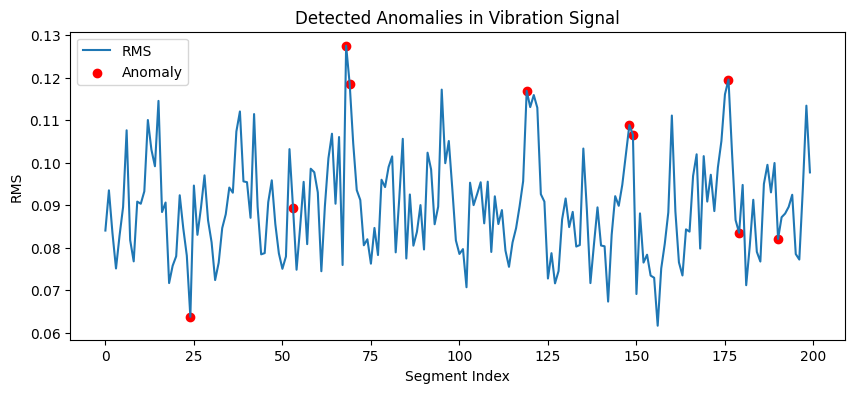

In [162]:
import matplotlib.pyplot as plt

rms_values = X[:,0]

plt.figure(figsize=(10,4))
plt.plot(rms_values, label="RMS")

plt.scatter(anomaly_indices,
            rms_values[anomaly_indices],
            color='red',
            label='Anomaly')

plt.xlabel("Segment Index")
plt.ylabel("RMS")
plt.title("Detected Anomalies in Vibration Signal")
plt.legend()
plt.show()

#### Did Hilbert Transformation for envelope analysis.


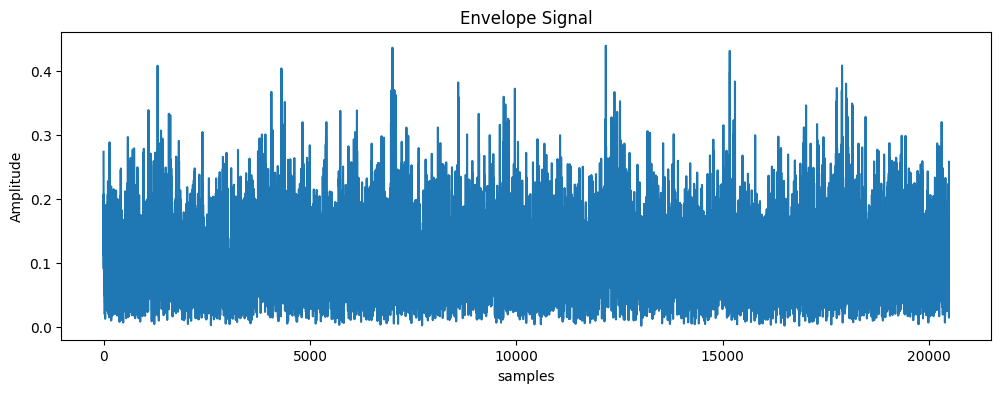

In [163]:
# Did envelope analysis cause FFT alone is not enough.
from scipy.signal import hilbert
signal=sig2
analytic_signal=hilbert(signal)
envelope=np.abs(analytic_signal)
plt.figure(figsize=(12,4))
plt.plot(envelope)
plt.title("Envelope Signal")
plt.xlabel("samples")
plt.ylabel("Amplitude")
plt.show()

#### Plotted envelope spectrum

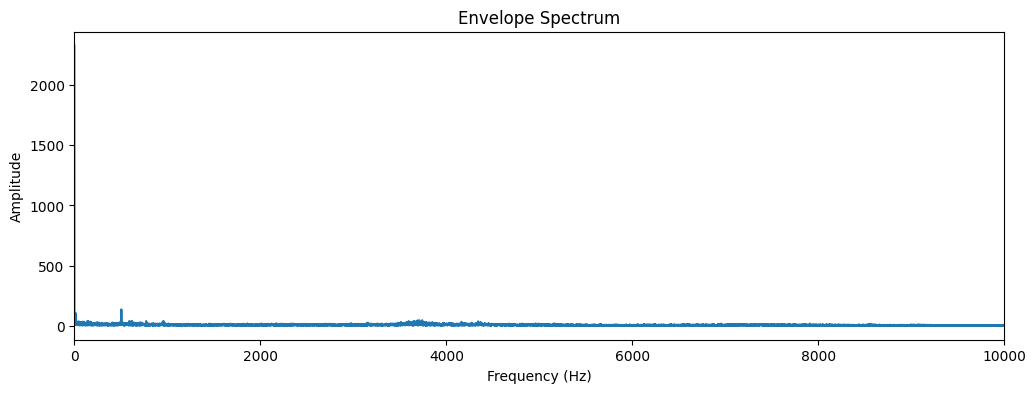

In [164]:
yf_env = np.abs(np.fft.rfft(envelope))

xf_env = np.fft.rfftfreq(len(envelope), 1/Fs)

plt.figure(figsize=(12,4))

plt.plot(xf_env, yf_env)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Envelope Spectrum")

plt.xlim(0,10000)

plt.show()

The result till now is "no fault" getting. If there have been a fault in the spectrum then the peaks would have been periodic and the frequency would be increasing constantly.

In [165]:
mask = (xf_env >= 500) & (xf_env <= 510)
xf_filtered = xf_env[mask]
yf_filtered = yf_env[mask]
print(yf_filtered)

[  8.52300576  10.30204341  21.87531609   6.69206908  15.97519778
 136.01788295  11.71853853   9.63929395   6.37548915  21.60294102
  13.80473685]


form the bove code i tried printing the y coordinate for the spikes from the spectrum of envelop. but turns out nothing is much wrong here, everythig is just normal.  

### Using OneClassSVM

In [166]:
# Moved to our next model for cross verification of the anamolies.
from sklearn.svm import OneClassSVM
svm_model=OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
svm_labels=svm_model.fit_predict(X_scaled)
print(svm_labels)

[ 1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1]


### Using Autoencoders

In [167]:
# One of the best models for anomalies detection as per the previous research.
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=16,
                verbose=0)

In [168]:
# did reconstruction as a part of our AE.
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - reconstructions)**2, axis=1)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [169]:
threshold = np.percentile(mse, 95)

ae_labels = np.where(mse > threshold, -1, 1)
print(ae_labels) # printing anomalies found by AE.

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1]


### Comparing results

In [170]:
print("Isolation Forest anomalies:", np.sum(labels == -1))
print("One-Class SVM anomalies:", np.sum(svm_labels == -1))
print("Autoencoder anomalies:", np.sum(ae_labels == -1))

Isolation Forest anomalies: 10
One-Class SVM anomalies: 18
Autoencoder anomalies: 10


### plotting of three models

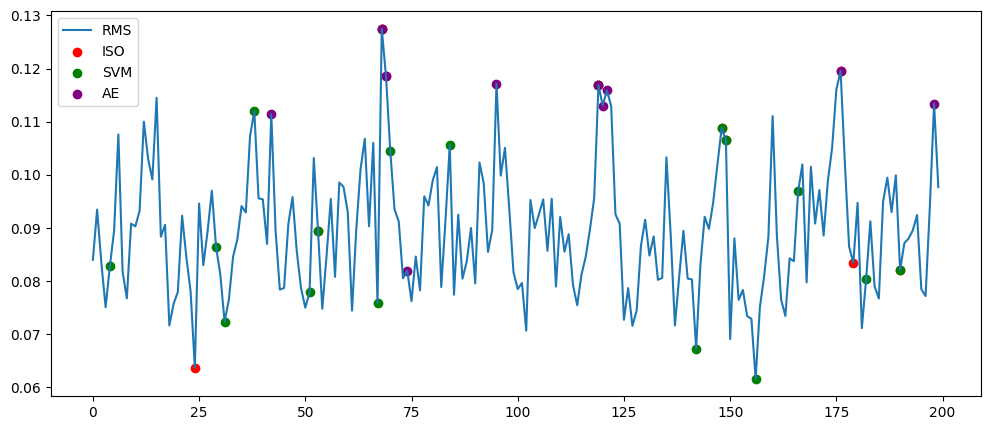

In [171]:
plt.figure(figsize=(12,5))

plt.plot(X[:,0], label="RMS")

plt.scatter(np.where(labels==-1),
            X[labels==-1,0],
            color='red', label='ISO')

plt.scatter(np.where(svm_labels==-1),
            X[svm_labels==-1,0],
            color='green', label='SVM')

plt.scatter(np.where(ae_labels==-1),
            X[ae_labels==-1,0],
            color='purple', label='AE')

plt.legend()
plt.show()

### Novelty: Creating a combined anomaly score for the best result.

In [172]:
combined = (labels == -1).astype(int) + \
           (svm_labels == -1).astype(int) + \
           (ae_labels == -1).astype(int)

# High confidence anomalies
strong_anomalies = np.where(combined >= 2)[0]
print(strong_anomalies)

[ 53  68  69 119 148 149 176 190]


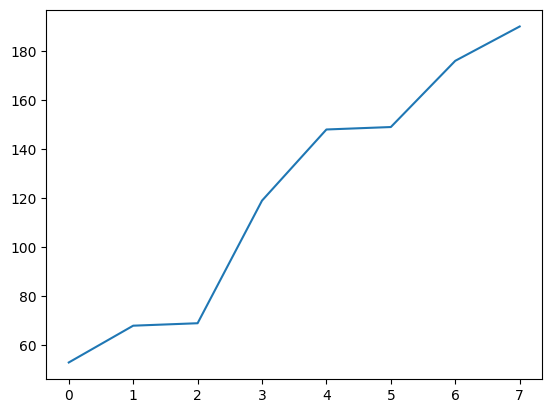

In [173]:
plt.plot(strong_anomalies)

### Counting anomaly over time for each second

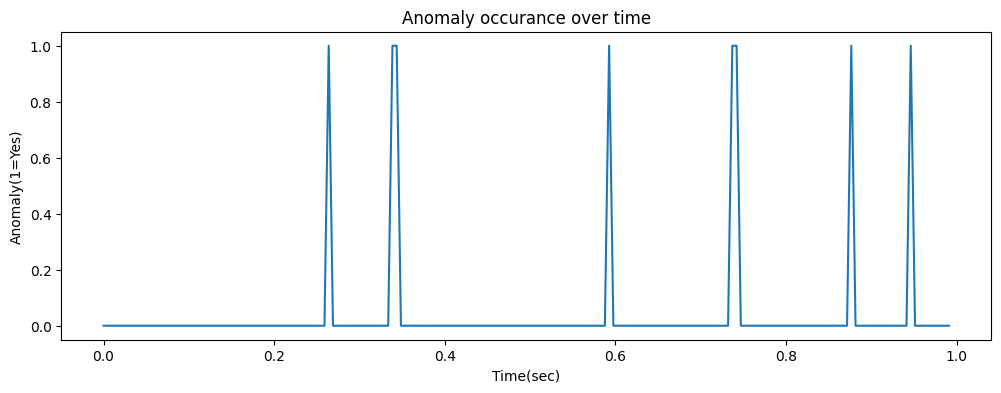

In [174]:
time=np.arange(len(X))*(window_size/Fs)
anomaly_signal=(combined>=2).astype(int)
plt.figure(figsize=(12,4))
plt.plot(time,anomaly_signal)
plt.xlabel("Time(sec)")
plt.ylabel("Anomaly(1=Yes)")
plt.title("Anomaly occurance over time")
plt.show()

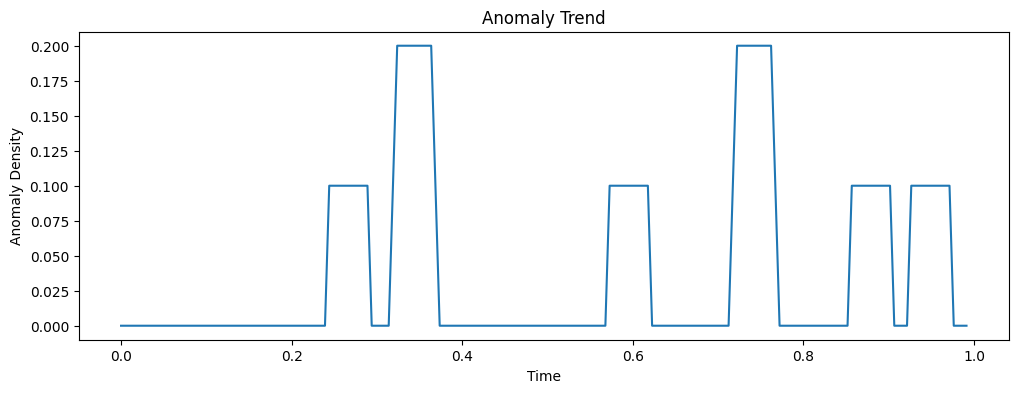

In [175]:
window = 10
trend = np.convolve(anomaly_signal, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,4))
plt.plot(time, trend)
plt.title("Anomaly Trend")
plt.xlabel("Time")
plt.ylabel("Anomaly Density")
plt.show()

Text(0.5, 1.0, 'rms over time')

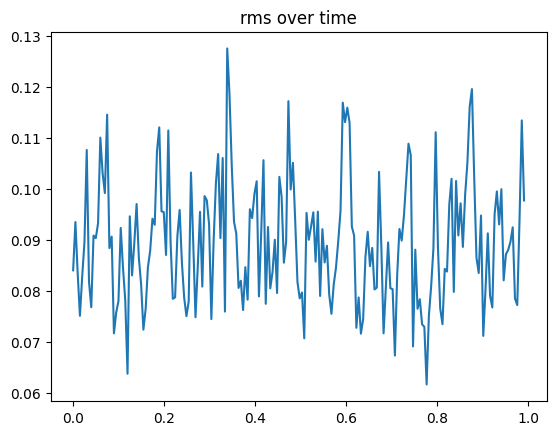

In [176]:
# plotting feature values individually.
plt.plot(time, X[:,0]) #in feature vector the index 0 is rms
plt.title("rms over time")

### Now we will check for multiple files and do some more work

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.signal import welch
from scipy.stats import kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

def extract_features(signal, Fs):
    rms = np.sqrt(np.mean(signal**2))
    std = np.std(signal)
    kurt = kurtosis(signal, fisher=False)

    freqs, psd = welch(signal, fs=Fs)

    centroid = np.sum(freqs * psd) / np.sum(psd)
    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd) / np.sum(psd))
    flatness = np.exp(np.mean(np.log(psd + 1e-12))) / np.mean(psd)

    psd_norm = psd / np.sum(psd)
    entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

    peak = np.max(np.abs(signal))
    mean_abs = np.mean(np.abs(signal))
    mean_sqrt = np.mean(np.sqrt(np.abs(signal)))

    crest = peak / rms
    shape = rms / mean_abs
    impulse = peak / mean_abs
    clearance = peak / (mean_sqrt**2)

    return [rms, std, kurt, centroid, bandwidth, flatness, entropy,
            crest, shape, impulse, clearance]



### Here we have defined segments again for the next all file work.

In [187]:
def create_segments(signal, Fs):
    window_size = Fs // 200
    segments = []

    for start in range(0, len(signal) - window_size + 1, window_size):
        segments.append(signal[start:start + window_size])

    return segments

### Loading AE

In [188]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(8, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='linear')(encoded)

    model = Model(inputs=input_layer, outputs=decoded)
    model.compile(optimizer='adam', loss='mse')

    return model

### Main pipeline

In [189]:
Fs = 20480
folder_path = "/filedata" # we have created one folder named "filedata" locally which consists of 38 files.

files = sorted(os.listdir(folder_path))

print("Files found:", files)

anomaly_counts = []

for file in files:
    print("\nProcessing:", file)

    # Load data
    file_path = os.path.join(folder_path, file)
    data = np.loadtxt(file_path)

    signal = data[:, 2]  # channel 2 only

    # Segmentation
    segments = create_segments(signal, Fs)

    # Feature extraction
    X = []
    for seg in segments:
        X.append(extract_features(seg, Fs))

    X = np.array(X)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Models ---

    # Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso_labels = iso.fit_predict(X_scaled)

    # One-Class SVM
    svm = OneClassSVM(nu=0.05, gamma='scale')
    svm_labels = svm.fit_predict(X_scaled)

    # Autoencoder
    ae = build_autoencoder(X_scaled.shape[1])
    ae.fit(X_scaled, X_scaled, epochs=20, batch_size=16, verbose=0)

    recon = ae.predict(X_scaled)
    mse = np.mean((X_scaled - recon)**2, axis=1)

    threshold = np.percentile(mse, 95)
    ae_labels = np.where(mse > threshold, -1, 1)

    # --- Ensemble ---
    combined = (iso_labels == -1).astype(int) + \
               (svm_labels == -1).astype(int) + \
               (ae_labels == -1).astype(int)

    strong_anomalies = np.where(combined >= 2)[0]

    count = len(strong_anomalies)
    anomaly_counts.append(count)

    print(f"Strong anomalies: {count}")

Files found: ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13', '2003.10.22.12.29.13', '2003.10.22.12.34.13', '2003.10.22.12.39.13', '2003.10.22.12.44.13', '2003.10.22.12.49.13', '2003.10.22.12.54.13', '2003.10.22.12.59.13', '2003.10.22.13.04.13', '2003.10.22.13.09.13', '2003.10.22.13.14.13', '2003.10.22.13.19.13', '2003.10.22.13.24.13', '2003.10.22.13.29.13', '2003.10.22.13.34.13', '2003.10.22.13.39.13', '2003.10.22.13.44.13', '2003.10.22.13.49.13', '2003.10.22.13.54.13', '2003.10.22.13.59.13', '2003.10.22.14.04.13', '2003.10.22.14.09.13', '2003.10.22.14.14.13', '2003.10.22.14.19.13', '2003.10.22.14.24.13', '2003.10.22.14.29.13', '2003.10.22.14.34.13', '2003.10.22.14.39.13', '2003.10.22.14.44.13', '2003.10.22.14.49.13', '2003.10.22.14.54.13', '2003.10.22.14.59.13', '2003.10.22.15.04.13', '2003.10.22.15.09.13']

Processing: 2003.10.22.12.06.24


/tmp/ipykernel_234/3473168330.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signal, fs=Fs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Strong anomalies: 10

Processing: 2003.10.22.12.09.13


/tmp/ipykernel_234/3473168330.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signal, fs=Fs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Strong anomalies: 9

Processing: 2003.10.22.12.14.13


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Strong anomalies: 13

Processing: 2003.10.22.15.04.13


/tmp/ipykernel_234/3473168330.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signal, fs=Fs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Strong anomalies: 12

Processing: 2003.10.22.15.09.13


/tmp/ipykernel_234/3473168330.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signal, fs=Fs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Strong anomalies: 9


### Plotting graph for multiple file index with anomaly count.

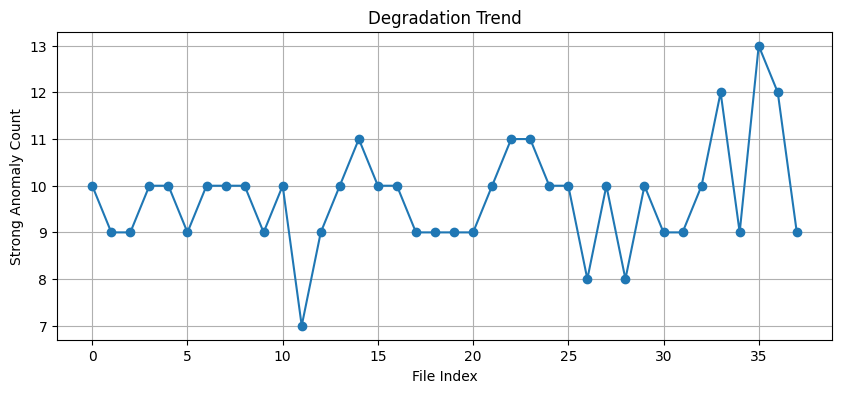

In [190]:
plt.figure(figsize=(10,4))
plt.plot(anomaly_counts, marker='o')

plt.xlabel("File Index")
plt.ylabel("Strong Anomaly Count")
plt.title("Degradation Trend")

plt.grid()
plt.show()

In [191]:
for i, count in enumerate(anomaly_counts):
    print(f"File {i}: {count} anomalies")

File 0: 10 anomalies
File 1: 9 anomalies
File 2: 9 anomalies
File 3: 10 anomalies
File 4: 10 anomalies
File 5: 9 anomalies
File 6: 10 anomalies
File 7: 10 anomalies
File 8: 10 anomalies
File 9: 9 anomalies
File 10: 10 anomalies
File 11: 7 anomalies
File 12: 9 anomalies
File 13: 10 anomalies
File 14: 11 anomalies
File 15: 10 anomalies
File 16: 10 anomalies
File 17: 9 anomalies
File 18: 9 anomalies
File 19: 9 anomalies
File 20: 9 anomalies
File 21: 10 anomalies
File 22: 11 anomalies
File 23: 11 anomalies
File 24: 10 anomalies
File 25: 10 anomalies
File 26: 8 anomalies
File 27: 10 anomalies
File 28: 8 anomalies
File 29: 10 anomalies
File 30: 9 anomalies
File 31: 9 anomalies
File 32: 10 anomalies
File 33: 12 anomalies
File 34: 9 anomalies
File 35: 13 anomalies
File 36: 12 anomalies
File 37: 9 anomalies


In [192]:
score = np.sum(combined)
print(score)

43
